# Stage 5: Model Evaluation

Goal: understand what each evaluation metric actually tells you in business terms, not just how to compute it.

Part A uses a logistic regression classifier on your cleaned Titanic data (classification metrics). Part B revisits your Stage 4 regression metrics with a business-framing lens.

## Part A: Classification Metrics

### 1. Rebuild your cleaned Titanic pipeline

Paste in the cleaning/encoding/split/scale cells from your Stage 3 notebook (fixed for the two leakage issues you caught: drop `alive`, and fit imputation/scaling after the split).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# Load
data = sns.load_dataset('titanic')

# Feature engineer (safe pre-split: pure row-wise arithmetic, no fitted statistics)
data['has_cabin'] = data['deck'].notna()
data['family_size'] = data['sibsp'] + data['parch'] + 1
data['fare_per_person'] = data['fare'] / data['family_size']

# Sex encoding (safe pre-split: deterministic remap, not a fitted statistic)
data['sex'] = data['sex'].map({'male': 0, 'female': 1})

# Drop target leakage columns
X = data.drop(columns=['survived', 'alive'])
y = data['survived']

# Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# Impute age (train-only stat, applied to all three splits)
median_age = X_train['age'].median()
X_train['age'] = X_train['age'].fillna(median_age)
X_val['age'] = X_val['age'].fillna(median_age)
X_test['age'] = X_test['age'].fillna(median_age)

# Impute embarked (train-only stat, applied to all three splits)
embarked_mode = X_train['embarked'].mode()[0]
X_train['embarked'] = X_train['embarked'].fillna(embarked_mode)
X_val['embarked'] = X_val['embarked'].fillna(embarked_mode)
X_test['embarked'] = X_test['embarked'].fillna(embarked_mode)

# Encode embarked (after imputation, fixed categories so all splits match)
for df in [X_train, X_val, X_test]:
    df['embarked'] = pd.Categorical(df['embarked'], categories=['C', 'Q', 'S'])

X_train = pd.get_dummies(X_train, columns=['embarked'], dtype=int)
X_val = pd.get_dummies(X_val, columns=['embarked'], dtype=int)
X_test = pd.get_dummies(X_test, columns=['embarked'], dtype=int)

# Scale numeric features (fit on train only)
numeric_features = ['age', 'fare', 'family_size', 'fare_per_person']
scaler = RobustScaler()
scaler.fit(X_train[numeric_features])


X_train[numeric_features] = scaler.transform(X_train[numeric_features])
X_val[numeric_features] = scaler.transform(X_val[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

# Drop remaining non-numeric/redundant columns your from-scratch math can't use
drop_cols = ['name', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alone']
X_train = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns])
X_val = X_val.drop(columns=[c for c in drop_cols if c in X_val.columns])
X_test = X_test.drop(columns=[c for c in drop_cols if c in X_test.columns])

# Convert to numpy arrays for the from-scratch functions
X_train_np, X_val_np = X_train.values.astype(float), X_val.values.astype(float)
y_train_np, y_val_np = y_train.values.astype(float), y_val.values.astype(float)

print(X_train.columns.tolist())
print(X_train_np.shape, X_val_np.shape)

['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'has_cabin', 'family_size', 'fare_per_person', 'embarked_C', 'embarked_Q', 'embarked_S']
(623, 12) (134, 12)


### 2. Train a logistic regression classifier

Use scikit-learn's `LogisticRegression` here (you already proved you understand the gradient descent mechanics in Stage 4 — no need to rebuild it from scratch for every algorithm, that would slow you down without teaching anything new).

In [26]:
from sklearn.linear_model import LogisticRegression

# TODO: fit LogisticRegression on X_train, y_train
# get both .predict() (hard labels) and .predict_proba() (probabilities) on X_val


model = LogisticRegression()
model.fit(X_train,y_train)
y_val_pred = model.predict(X_val)
y_val_pred_proba = model.predict_proba(X_val)[:, 1]



### 3. Confusion matrix — start here, always

Every other classification metric is computed from these four numbers: true positives, false positives, true negatives, false negatives.

Guiding questions:
- In the Titanic context, what does a false positive mean (predicted survived, actually died)? What does a false negative mean?
- Look at the raw counts before computing any derived metric — does anything jump out (e.g., is the model just predicting the majority class most of the time)?

Answer:
- A FP means that we predicted someone would live but actually die, FN means opposite


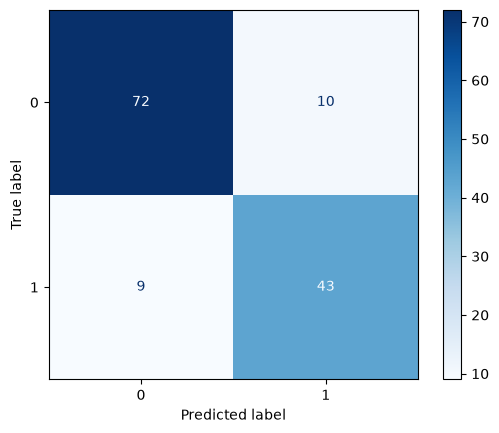

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# TODO: compute and plot the confusion matrix on validation predictions
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
)

#TP= cm[0][0]
#FP= cm[0][1]
#FN= cm[0][1]
#TN= cm[1][1]
TN, FP, FN, TP = cm.ravel()
disp.plot(cmap=plt.cm.Blues, values_format='d')

### 4. Precision, recall, F1 — implement from scratch first

Implement these using only the confusion matrix counts (TP, FP, TN, FN) — not `sklearn.metrics` yet. This forces you to internalize what each formula actually measures.

- Precision = TP / (TP + FP) — "of what I flagged as positive, how much was actually positive?"
- Recall = TP / (TP + FN) — "of what was actually positive, how much did I catch?"
- F1 = harmonic mean of precision and recall

Guiding question: for this specific problem (predicting survival), would you rather optimize for precision or recall if this were a real triage system deciding who to prioritize rescuing? Why?

In [20]:
# TODO: compute precision, recall, F1 manually from TP/FP/TN/FN

precision = TP/ (TP+FP)
recall = TP/ (TP+FN)

F1 = 2* (precision*recall) /(precision+recall)

print(precision)
print(recall)
print(F1)



0.8113207547169812
0.8269230769230769
0.819047619047619


In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# TODO: confirm your manual numbers match sklearn's
precision_sklearn = precision_score(y_val, y_val_pred)
recall_sklearn = recall_score(y_val, y_val_pred)
f1_sklearn = f1_score(y_val, y_val_pred)

print(precision_sklearn)
print(recall_sklearn)
print(f1_sklearn)


0.8113207547169812
0.8269230769230769
0.819047619047619


### 5. ROC-AUC and PR-AUC

These use `predict_proba()`, not hard labels — they evaluate ranking quality across every possible decision threshold at once.

Guiding questions:
- Plot both curves. What does the diagonal line on the ROC curve represent?
- Titanic survival isn't heavily imbalanced, so ROC-AUC and PR-AUC should roughly agree here. In a *heavily* imbalanced problem (like fraud, ~0.2% positive), why would PR-AUC tell a more honest story than ROC-AUC? (Think about what a high false-positive rate does to each curve's shape when negatives vastly outnumber positives.)

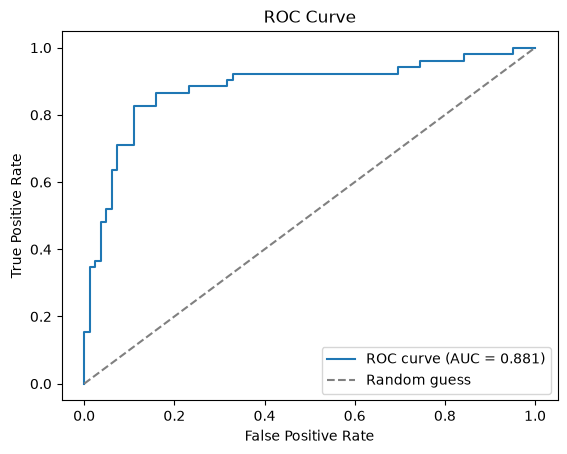

0.8806285178236398


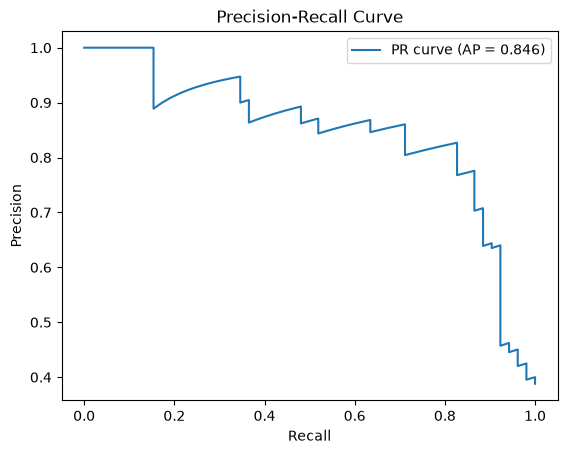

0.8457115712781191


In [38]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
y_val_proba_1 = y_val_pred_proba

fpr, tpr, thresholds_roc = roc_curve(y_val, y_val_proba_1)
roc_auc = roc_auc_score(y_val, y_val_proba_1)



plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
print(roc_auc)



precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_val, y_val_proba_1)
avg_precision = average_precision_score(y_val, y_val_proba_1)

plt.plot(recall_vals, precision_vals, label=f"PR curve (AP = {avg_precision:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

print(avg_precision)

### 6. Threshold tuning — the business decision

By default, `.predict()` uses a 0.5 probability threshold. But the "right" threshold depends on which error type is more costly in context.

Guiding exercise: sweep thresholds from 0.1 to 0.9, and at each one, recompute precision and recall using `predict_proba()` output. Plot precision and recall vs. threshold on the same chart. Pick a threshold and justify your choice as if explaining it to a non-technical stakeholder.

e set the threshold at 0.35 instead of 0.5 because in a life-safety context, failing to help someone who needed it is a far more serious error than over-helping someone who didn't — this threshold catches about 88% of people who would actually survive, at the cost of some false alarms

[np.float64(0.43859649122807015), np.float64(0.5393258426966292), np.float64(0.6388888888888888), np.float64(0.6666666666666666), np.float64(0.7076923076923077), np.float64(0.7377049180327869), np.float64(0.7627118644067796), np.float64(0.7678571428571429), np.float64(0.8113207547169812), np.float64(0.8222222222222222), np.float64(0.8536585365853658), np.float64(0.8648648648648649), np.float64(0.8484848484848485), np.float64(0.88), np.float64(0.9473684210526315), np.float64(0.9333333333333333), np.float64(0.9), np.float64(1.0)]
[np.float64(0.9615384615384616), np.float64(0.9230769230769231), np.float64(0.8846153846153846), np.float64(0.8846153846153846), np.float64(0.8846153846153846), np.float64(0.8653846153846154), np.float64(0.8653846153846154), np.float64(0.8269230769230769), np.float64(0.8269230769230769), np.float64(0.7115384615384616), np.float64(0.6730769230769231), np.float64(0.6153846153846154), np.float64(0.5384615384615384), np.float64(0.4230769230769231), np.float64(0.3461

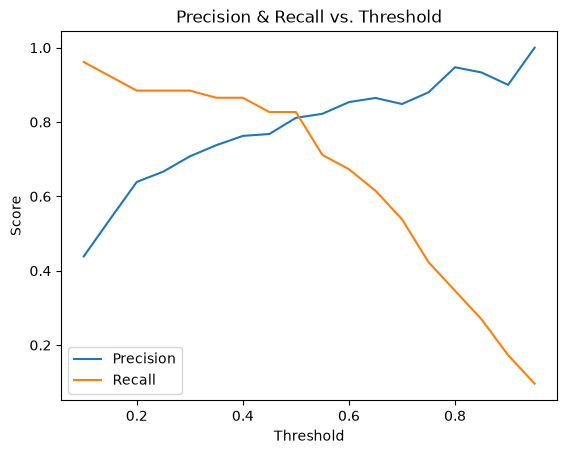

In [42]:
# TODO: threshold sweep, plot precision/recall vs threshold

thresholds_to_test = np.arange(0.1, 1.0, 0.05)
precisions = []
recalls = []

for t in thresholds_to_test:
    y_pred_t = (y_val_proba_1 >= t).astype(int)
    cm = confusion_matrix(y_val, y_pred_t)
    TTN, TFP, TFN, TTP = cm.ravel()
    precisions.append(TTP/(TTP+TFP))
    recalls.append( TTP/ (TTP+TFN))


print(precisions)
print(recalls)


plt.plot(thresholds_to_test, precisions, label="Precision")
plt.plot(thresholds_to_test, recalls, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs. Threshold")
plt.legend()
plt.show()

### 7. Cross-validation

A single train/val split gives you one estimate of performance — it could be lucky or unlucky. K-fold cross-validation gives you a distribution of scores instead.

Guiding question: if your 5-fold CV scores are [0.79, 0.81, 0.78, 0.83, 0.80], what does that spread tell you about how much to trust your single validation-set number from earlier?

In [44]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(LogisticRegression(), X_train, y_train, cv=10, scoring='accuracy')
print(cv_scores)
print(f"Mean: {cv_scores.mean():.4f}, Std: {cv_scores.std():.4f}")




[0.80952381 0.82539683 0.74603175 0.82258065 0.77419355 0.88709677
 0.77419355 0.79032258 0.85483871 0.74193548]
Mean: 0.8026, Std: 0.0441


## Part B: Regression Metrics Revisited

You already implemented MAE, RMSE, R² from scratch in Stage 4. This section is about the business-framing layer on top of the math.

Guiding questions (answer in markdown, referencing your Stage 4 house price numbers):
- MAE is in the same units as the target (dollars, in this case). If your MAE was, say, $45,000 on a dataset where median home value is ~$200,000 — is that a good model? How would you explain that number to someone who has never heard of MAE?
- Why does RMSE penalize large errors more than MAE? When would that matter in a real business (e.g., a housing price model that's occasionally off by $500k vs. one that's consistently off by $50k)?
- What does R² = 0 mean? What does R² = 1 mean? What does a negative R² mean (this can actually happen — look it up if you're unsure)? 

_Your answers here._

- Yes, I tihnk 45,000 on a dataset where a median home value is 200,000 is not bad nor good. It just means that it gets it wrong 45,000+ or 45,000-, the model is off by about 22.5%, and the real value of a home could be from 155-245.
- RMSE penalize large errors more than MAE because of the square factor on the predictions. So values that are off by a lot get heavily penalize so and house off by 50,000 would not recieve the same treatment.
- R^2 explains how much variation can the model catch. 0 means the model is doing just as good as the mean. (1) means that the model is catching the variation and predictions are perfect, (-1) means that the model is doing worse than the mean (something is broken or not working correctly)




## Wrap-up

Write a short "model report card" for your Titanic classifier: confusion matrix summary, precision/recall/F1, ROC-AUC/PR-AUC, your chosen threshold and why, and cross-validation stability. Write it as if presenting to a non-technical stakeholder deciding whether to trust this model.


The confusion matrix we obtained is that we had about TN=72,FP=10,FN=9,TP=43. Precision sat at 81% and recall at 82%, and F1 at .81%. This meant that our model was great at identifying true negatives and true positives. The model made a reasonable number of both error types, roughly balanced between false positives and false negatives, rather than being skewed toward one failure mode. Our Roc curve sat 88% and PR curve at 84%. Our chosen threshold was 35%-40%, and the reason for this is because we believe that it is better to have a higher recall rate with an acceptable precision rate in knowing that we can in a life context situtation help those who may not need it than the opposite. Based on cross-validation, we estimate this model's real-world accuracy at roughly 80% — a solid baseline, though not as strong as the single-split evaluation initially suggested."